In [1]:
from google.colab import drive

drive.mount('/content/drive')

# 認証が完了すると、「drive/My Drive」以下にgoogle driveのルートがマウントされる。

Mounted at /content/drive


In [ ]:
import pandas as pd

# CSVの読み込み
vis = pd.read_csv("/content/drive/MyDrive/Data/tourism-analysis/foreign_visitors_yearly.csv")
exp = pd.read_csv("/content/drive/MyDrive/Data/tourism-analysis/expenditure_per_foreign_tourist.csv")
fx = pd.read_csv("/content/drive/MyDrive/Data/tourism-analysis/exchange_rate_monthly.csv", encoding="shift-jis",
                 skiprows=2, names=["date", "usd_jpy", "reer"])

# 列の調整
exp.columns = exp.columns.str.strip()

# Year → yearに統一
vis = vis.rename(columns={"Year": "year"})
exp = exp.rename(columns={"Year": "year"})

In [2]:
# 為替データ
# 年を取り出す
fx["year"] = fx["date"].str[:4].astype(int)

# 為替レートの年平均を計算
yearly = fx.groupby("year")["usd_jpy"].mean().reset_index()

# 保存
yearly.to_csv("/content/drive/MyDrive/Data/tourism-analysis/exchange_rate_yearly.csv", index=False)

fx = yearly.copy()

fx.head()

In [ ]:
# 結合
df = exp.merge(vis, on="year").merge(fx, on="year")

df.to_csv("/content/drive/MyDrive/Data/tourism-analysis/tourism_merged.csv", index=False)

df.head()

,year,Consumption Amount,Visitor Arrivals,Growth Rate(%),Term,usd_jpy
0,2011,"130,819","6,218,752",-27.782770644,Jan. - Dec.,79.780833
1,2012,"129,798","8,358,105",34.401645218,Jan. - Dec.,79.789167
2,2013,"136,693","10,363,904",23.998250800,Jan. - Dec.,97.600000
3,2014,"151,174","13,413,467",29.424848011,Jan. - Dec.,105.835833
4,2015,"176,167","19,737,409",47.146215069,Jan. - Dec.,121.021667


In [48]:
import pandas as pd

# 結合CSVの読み込み
# df = pd.read_csv("/content/drive/MyDrive/Data/tourism-analysis/tourism_merged.csv")

# 型変換（object → int）
df["Consumption Amount"] = df["Consumption Amount"].str.replace(",", "").astype(int)
df["Visitor Arrivals"] = df["Visitor Arrivals"].str.replace(",", "").astype(int)

# Term列の削除
df = df.drop("Term", axis=1)

# 外れ値（2023年）の削除
df = df.drop(index=9).reset_index(drop=True)

df.dtypes

,0
year,int64
Consumption Amount,int64
Visitor Arrivals,int64
Growth Rate(%),float64
usd_jpy,float64


In [27]:
# 相関
df.corr(numeric_only=True)

,year,Consumption Amount,Visitor Arrivals,Growth Rate(%),usd_jpy
year,1.000000,0.903023,0.868324,0.540515,0.918484
Consumption Amount,0.903023,1.000000,0.670619,0.587464,0.966162
Visitor Arrivals,0.868324,0.670619,1.000000,0.142444,0.767268
Growth Rate(%),0.540515,0.587464,0.142444,1.000000,0.517056
usd_jpy,0.918484,0.966162,0.767268,0.517056,1.000000


##　相関分析の結果
#### ・Growth Rate(%) と usd_jpy の相関係数は 0.517 であり、円安になると訪日客の増加率が上昇する傾向が確認された（中程度の相関）。
#### ・year と usd_jpy の相関は 0.918 と非常に高く、時間の経過とともに円安が進行していることが確認された。このため year は分析対象から除外する。
#### ・円安と訪日客数には 比較的強い相関（0.767） が確認された。
#### ・一方、為替と観光消費額の相関（0.966）は、時間トレンドの影響を受けた トレンド相関 の可能性が高い。
#### ・訪日客数と消費額には 中程度の相関（0.671） が確認され、観光客数の増加が消費拡大に寄与している可能性がある。
----------------
## 考察
考察
本分析から、円安はインバウンド増加の要因の一つである可能性が示唆された。ただし、インバウンド需要は為替以外にも、以下の要因の影響を受けるため、為替のみで説明することはできない。

#####・ビザ緩和
#####・LCC増加
#####・中国観光客
#####・コロナ
----------------
## 結論（仮）
円安は訪日客増加と一定の関連を持つが、インバウンド増加の唯一の要因ではない。


<!-- 年次推移（訪日客数 / 為替 / 消費） -->

# 年次推移（訪日客数 / 為替 / 消費）

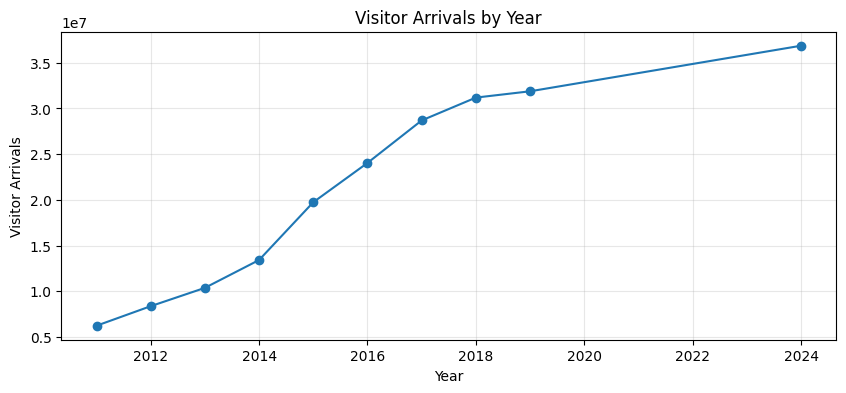

In [43]:
import matplotlib.pyplot as plt

# ① 訪日客数（年次）
plt.figure(figsize=(10,4))
plt.plot(df["year"], df["Visitor Arrivals"], marker="o")
plt.xlabel("Year")
plt.ylabel("Visitor Arrivals")
plt.title("Visitor Arrivals by Year")
plt.grid(True, alpha=0.3)
plt.show()

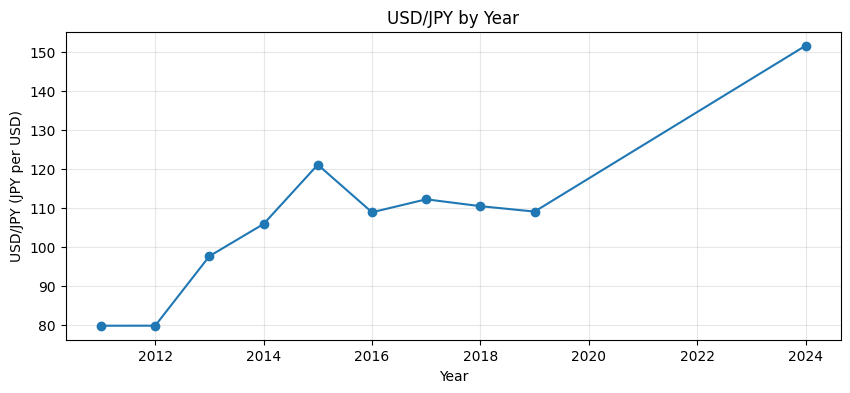

In [44]:
# ② 為替（年次）
plt.figure(figsize=(10,4))
plt.plot(df["year"], df["usd_jpy"], marker="o")
plt.xlabel("Year")
plt.ylabel("USD/JPY (JPY per USD)")
plt.title("USD/JPY by Year")
plt.grid(True, alpha=0.3)
plt.show()

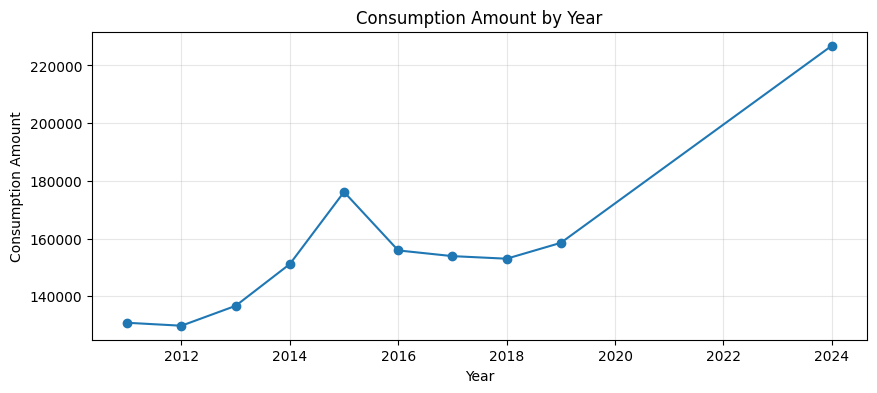

In [45]:
# ③ 消費額（年次）
plt.figure(figsize=(10,4))
plt.plot(df["year"], df["Consumption Amount"], marker="o")
plt.xlabel("Year")
plt.ylabel("Consumption Amount")
plt.title("Consumption Amount by Year")
plt.grid(True, alpha=0.3)
plt.show()

# 回帰線付き散布図（為替 × 訪日客数）
為替レートと訪日客数の関係を直線で近似して視覚化

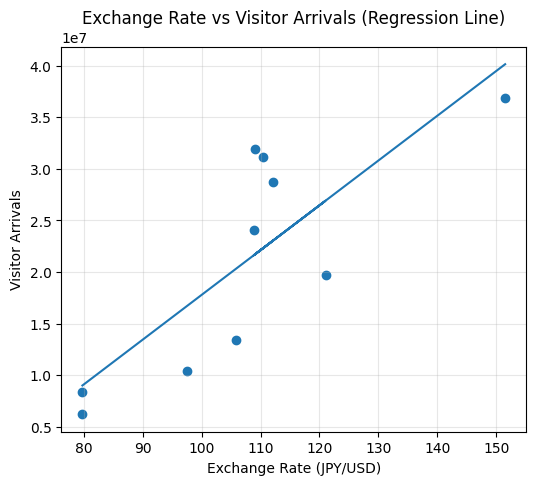

In [46]:
import numpy as np
import matplotlib.pyplot as plt

x = df["usd_jpy"]
y = df["Visitor Arrivals"]

plt.figure(figsize=(6,5))
plt.scatter(x, y)

plt.xlabel("Exchange Rate (JPY/USD)")
plt.ylabel("Visitor Arrivals")
plt.title("Exchange Rate vs Visitor Arrivals (Regression Line)")

plt.grid(True, alpha=0.3)

# -----回帰線-----
# 年平均のドル円為替レートを説明変数、訪日客数を目的変数として単回帰分析を行った。
# NumPy の polyfit() 関数を用いて最小二乗法により回帰式
# VisitorArrivals=m×USDJPY+b
# を推定し、その回帰直線を Matplotlib により可視化した。
# -----English-----
# A simple linear regression was estimated using the annual average USD/JPY exchange rate as the explanatory
# variable and the number of visitor arrivals as the dependent variable.
# The regression coefficients were calculated using NumPy’s polyfit() function based on the least squares method,
# and the regression line was visualized using Matplotlib.
# ---補足---
# m（傾き）→ 為替レートが1円変化したとき、訪日客数がどれだけ変化するか
# b（切片）→ 為替が0円だったと仮定した場合の訪日客数（※実際の意味はほぼない）
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b)

# 写真
# plt.savefig("/content/drive/MyDrive/Data/tourism-analysis/exchange_vs_visitors.png")

plt.show()

(11, 6)


,year,Consumption Amount,Visitor Arrivals,Growth Rate(%),Term,usd_jpy
0,2011,130819,6218752,-27.782771,Jan. - Dec.,79.780833
1,2012,129798,8358105,34.401645,Jan. - Dec.,79.789167
2,2013,136693,10363904,23.998251,Jan. - Dec.,97.600000
3,2014,151174,13413467,29.424848,Jan. - Dec.,105.835833
4,2015,176167,19737409,47.146215,Jan. - Dec.,121.021667
5,2016,155896,24039700,21.797648,Jan. - Dec.,108.835833
6,2017,153921,28691073,19.348715,Jan. - Dec.,112.159167
7,2018,153029,31191856,8.716241,Jan. - Dec.,110.402500
8,2019,158531,31882049,2.212735,Jan. - Dec.,109.013333
9,2023,212764,25066350,554.113530,Jan. - Dec.,140.507500


#　回帰分析

### 「為替 → 観光客数」

In [49]:
import statsmodels.api as sm

# 説明変数
X = df["usd_jpy"]

# 定数項追加
X = sm.add_constant(X)

# 目的変数
y = df["Visitor Arrivals"]

# 回帰
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       Visitor Arrivals   R-squared:                       0.653
Model:                            OLS   Adj. R-squared:                  0.610
Method:                 Least Squares   F-statistic:                     15.07
Date:                Thu, 05 Mar 2026   Prob (F-statistic):            0.00466
Time:                        13:54:06   Log-Likelihood:                -170.52
No. Observations:                  10   AIC:                             345.0
Df Residuals:                       8   BIC:                             345.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2.563e+07   1.22e+07     -2.096      0.0

- usd_jpy   coef = 4.341e+05　から、為替が1円円安になると
約43万人訪日客が増えることがわかる。
- P>|t| = 0.005（統計的に非常に有意）
- R-squared = 0.653は、訪日客数の変動の65%を為替が説明している。
- Prob (F-statistic) = 0.00466から、このモデルは統計的に有意。為替 → 訪日客という関係は偶然ではない可能性が高い。

###「観光客数 → 消費額」

In [50]:
import statsmodels.api as sm

# 説明変数
X = df["Visitor Arrivals"]

# 定数追加
X = sm.add_constant(X)

# 目的変数
y = df["Consumption Amount"]

# 回帰
model = sm.OLS(y, X).fit()

# 結果
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     Consumption Amount   R-squared:                       0.525
Model:                            OLS   Adj. R-squared:                  0.465
Method:                 Least Squares   F-statistic:                     8.828
Date:                Thu, 05 Mar 2026   Prob (F-statistic):             0.0178
Time:                        14:10:35   Log-Likelihood:                -112.41
No. Observations:                  10   AIC:                             228.8
Df Residuals:                       8   BIC:                             229.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             1.183e+05   1.47e+04  

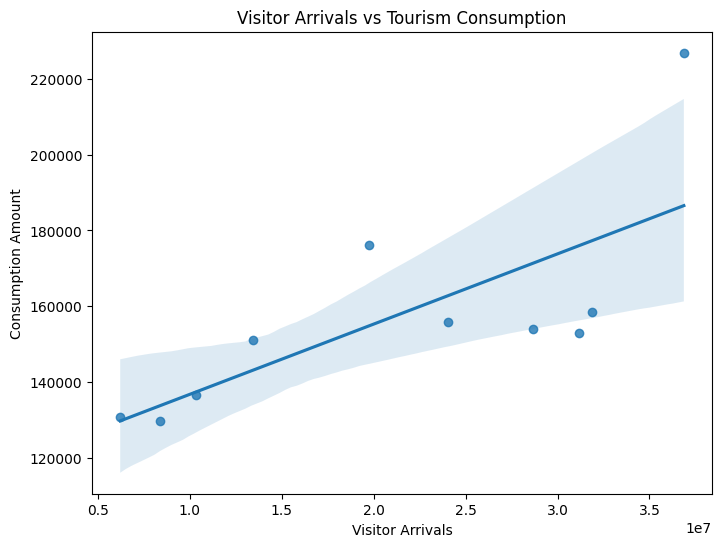

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.regplot(
    x=df["Visitor Arrivals"],
    y=df["Consumption Amount"]
)

plt.title("Visitor Arrivals vs Tourism Consumption")
plt.xlabel("Visitor Arrivals")
plt.ylabel("Consumption Amount")

# 保存
plt.savefig("/content/drive/MyDrive/Data/tourism-analysis/visitors_vs_consumption.png")

plt.show()